In [1]:
import pandas as pd
import numpy as np

In [2]:
from sklearn.datasets import make_regression

In [3]:
X, y = make_regression(n_samples=10,n_features=3)

In [4]:
X

array([[ 0.25273891,  1.87061139, -0.92606312],
       [ 0.5347423 ,  0.39780339,  0.32324946],
       [-1.02332616, -0.13942021,  0.08562954],
       [ 2.16210132, -0.36135377, -1.14470084],
       [-0.17140948,  0.17191673, -0.52186924],
       [-0.0973471 ,  0.384453  ,  0.20113511],
       [-1.05564574,  0.49503549,  1.15367359],
       [ 0.29766467,  0.90589249, -0.44528054],
       [ 0.92103176,  0.59152582,  0.14125638],
       [-1.89723203, -0.84301161, -0.31989878]])

In [5]:
y

array([-18.14625998,  29.95833159,  -2.25529391, -66.75423065,
       -29.09991571,  19.36962669,  75.026272  ,  -7.788409  ,
        24.50349195, -44.81357829])

In [6]:
df = pd.DataFrame(X)

In [9]:
df

,0,1,2,y_true,y_pred_0
0,0.252739,1.870611,-0.926063,-18.146260,-1.999997
1,0.534742,0.397803,0.323249,29.958332,-1.999997
2,-1.023326,-0.139420,0.085630,-2.255294,-1.999997
3,2.162101,-0.361354,-1.144701,-66.754231,-1.999997
4,-0.171409,0.171917,-0.521869,-29.099916,-1.999997
5,-0.097347,0.384453,0.201135,19.369627,-1.999997
6,-1.055646,0.495035,1.153674,75.026272,-1.999997
7,0.297665,0.905892,-0.445281,-7.788409,-1.999997
8,0.921032,0.591526,0.141256,24.503492,-1.999997
9,-1.897232,-0.843012,-0.319899,-44.813578,-1.999997


In [7]:
df['y_true'] = y

In [8]:
df['y_pred_0'] = df['y_true'].mean()

In [10]:
df

,0,1,2,y_true,y_pred_0
0,0.252739,1.870611,-0.926063,-18.146260,-1.999997
1,0.534742,0.397803,0.323249,29.958332,-1.999997
2,-1.023326,-0.139420,0.085630,-2.255294,-1.999997
3,2.162101,-0.361354,-1.144701,-66.754231,-1.999997
4,-0.171409,0.171917,-0.521869,-29.099916,-1.999997
5,-0.097347,0.384453,0.201135,19.369627,-1.999997
6,-1.055646,0.495035,1.153674,75.026272,-1.999997
7,0.297665,0.905892,-0.445281,-7.788409,-1.999997
8,0.921032,0.591526,0.141256,24.503492,-1.999997
9,-1.897232,-0.843012,-0.319899,-44.813578,-1.999997


In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [12]:
mean_absolute_error(df['y_true'],df['y_pred_0'])

31.371541671252096

In [13]:
df['residual_0'] = df['y_true'] - df['y_pred_0']

In [14]:
df

,0,1,2,y_true,y_pred_0,residual_0
0,0.252739,1.870611,-0.926063,-18.146260,-1.999997,-16.146263
1,0.534742,0.397803,0.323249,29.958332,-1.999997,31.958328
2,-1.023326,-0.139420,0.085630,-2.255294,-1.999997,-0.255297
3,2.162101,-0.361354,-1.144701,-66.754231,-1.999997,-64.754234
4,-0.171409,0.171917,-0.521869,-29.099916,-1.999997,-27.099919
5,-0.097347,0.384453,0.201135,19.369627,-1.999997,21.369623
6,-1.055646,0.495035,1.153674,75.026272,-1.999997,77.026269
7,0.297665,0.905892,-0.445281,-7.788409,-1.999997,-5.788412
8,0.921032,0.591526,0.141256,24.503492,-1.999997,26.503488
9,-1.897232,-0.843012,-0.319899,-44.813578,-1.999997,-42.813582


In [15]:
from sklearn.tree import DecisionTreeRegressor

In [16]:
tree_1 = DecisionTreeRegressor(max_depth=1)

In [17]:
tree_1.fit(df[[0,1,2]],df['residual_0'])

DecisionTreeRegressor(max_depth=1)

In [18]:
df['tree_pred_1'] = tree_1.predict(df[[0,1,2]])

In [19]:
df

,0,1,2,y_true,y_pred_0,residual_0,tree_pred_1
0,0.252739,1.870611,-0.926063,-18.146260,-1.999997,-16.146263,-26.142951
1,0.534742,0.397803,0.323249,29.958332,-1.999997,31.958328,39.214427
2,-1.023326,-0.139420,0.085630,-2.255294,-1.999997,-0.255297,-26.142951
3,2.162101,-0.361354,-1.144701,-66.754231,-1.999997,-64.754234,-26.142951
4,-0.171409,0.171917,-0.521869,-29.099916,-1.999997,-27.099919,-26.142951
5,-0.097347,0.384453,0.201135,19.369627,-1.999997,21.369623,39.214427
6,-1.055646,0.495035,1.153674,75.026272,-1.999997,77.026269,39.214427
7,0.297665,0.905892,-0.445281,-7.788409,-1.999997,-5.788412,-26.142951
8,0.921032,0.591526,0.141256,24.503492,-1.999997,26.503488,39.214427
9,-1.897232,-0.843012,-0.319899,-44.813578,-1.999997,-42.813582,-26.142951


In [20]:
from sklearn.tree import plot_tree

[Text(0.5, 0.75, 'x[2] <= 0.113\nsquared_error = 1516.827\nsamples = 10\nvalue = 0.0'),
 Text(0.25, 0.25, 'squared_error = 492.345\nsamples = 6\nvalue = -26.143'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'squared_error = 490.598\nsamples = 4\nvalue = 39.214'),
 Text(0.625, 0.5, '  False')]

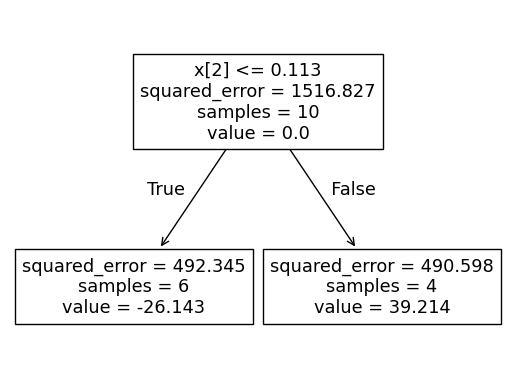

In [21]:
plot_tree(tree_1)

In [ ]:
nu = 0.1 #learning rate

In [23]:
df['y_pred_1'] = df['y_pred_0'] + nu*df['tree_pred_1']

In [24]:
df

,0,1,2,y_true,y_pred_0,residual_0,tree_pred_1,y_pred_1
0,0.252739,1.870611,-0.926063,-18.146260,-1.999997,-16.146263,-26.142951,-4.614292
1,0.534742,0.397803,0.323249,29.958332,-1.999997,31.958328,39.214427,1.921446
2,-1.023326,-0.139420,0.085630,-2.255294,-1.999997,-0.255297,-26.142951,-4.614292
3,2.162101,-0.361354,-1.144701,-66.754231,-1.999997,-64.754234,-26.142951,-4.614292
4,-0.171409,0.171917,-0.521869,-29.099916,-1.999997,-27.099919,-26.142951,-4.614292
5,-0.097347,0.384453,0.201135,19.369627,-1.999997,21.369623,39.214427,1.921446
6,-1.055646,0.495035,1.153674,75.026272,-1.999997,77.026269,39.214427,1.921446
7,0.297665,0.905892,-0.445281,-7.788409,-1.999997,-5.788412,-26.142951,-4.614292
8,0.921032,0.591526,0.141256,24.503492,-1.999997,26.503488,39.214427,1.921446
9,-1.897232,-0.843012,-0.319899,-44.813578,-1.999997,-42.813582,-26.142951,-4.614292


In [25]:
mean_absolute_error(df['y_true'],df['y_pred_0'])

31.371541671252096

In [26]:
mean_absolute_error(df['y_true'],df['y_pred_1'])

28.706187056800577

In [30]:
df

,0,1,2,y_true,y_pred_0,residual_0,tree_pred_1,y_pred_1
0,0.252739,1.870611,-0.926063,-18.146260,-1.999997,-16.146263,-26.142951,-4.614292
1,0.534742,0.397803,0.323249,29.958332,-1.999997,31.958328,39.214427,1.921446
2,-1.023326,-0.139420,0.085630,-2.255294,-1.999997,-0.255297,-26.142951,-4.614292
3,2.162101,-0.361354,-1.144701,-66.754231,-1.999997,-64.754234,-26.142951,-4.614292
4,-0.171409,0.171917,-0.521869,-29.099916,-1.999997,-27.099919,-26.142951,-4.614292
5,-0.097347,0.384453,0.201135,19.369627,-1.999997,21.369623,39.214427,1.921446
6,-1.055646,0.495035,1.153674,75.026272,-1.999997,77.026269,39.214427,1.921446
7,0.297665,0.905892,-0.445281,-7.788409,-1.999997,-5.788412,-26.142951,-4.614292
8,0.921032,0.591526,0.141256,24.503492,-1.999997,26.503488,39.214427,1.921446
9,-1.897232,-0.843012,-0.319899,-44.813578,-1.999997,-42.813582,-26.142951,-4.614292


In [31]:
df['residual_1'] = df['y_true'] - df['y_pred_1']

In [32]:
df

,0,1,2,y_true,y_pred_0,residual_0,tree_pred_1,y_pred_1,residual_1
0,0.252739,1.870611,-0.926063,-18.146260,-1.999997,-16.146263,-26.142951,-4.614292,-13.531968
1,0.534742,0.397803,0.323249,29.958332,-1.999997,31.958328,39.214427,1.921446,28.036885
2,-1.023326,-0.139420,0.085630,-2.255294,-1.999997,-0.255297,-26.142951,-4.614292,2.358998
3,2.162101,-0.361354,-1.144701,-66.754231,-1.999997,-64.754234,-26.142951,-4.614292,-62.139939
4,-0.171409,0.171917,-0.521869,-29.099916,-1.999997,-27.099919,-26.142951,-4.614292,-24.485624
5,-0.097347,0.384453,0.201135,19.369627,-1.999997,21.369623,39.214427,1.921446,17.448181
6,-1.055646,0.495035,1.153674,75.026272,-1.999997,77.026269,39.214427,1.921446,73.104826
7,0.297665,0.905892,-0.445281,-7.788409,-1.999997,-5.788412,-26.142951,-4.614292,-3.174117
8,0.921032,0.591526,0.141256,24.503492,-1.999997,26.503488,39.214427,1.921446,22.582046
9,-1.897232,-0.843012,-0.319899,-44.813578,-1.999997,-42.813582,-26.142951,-4.614292,-40.199287


In [33]:
tree_2 = DecisionTreeRegressor(max_depth=1)

In [34]:
tree_2.fit(df[[0,1,2]],df['residual_1'])

DecisionTreeRegressor(max_depth=1)

In [35]:
df['y_pred_2'] = df['y_pred_1'] + nu * tree_2.predict(df[[0,1,2]])

In [36]:
df

,0,1,2,y_true,y_pred_0,residual_0,tree_pred_1,y_pred_1,residual_1,y_pred_2
0,0.252739,1.870611,-0.926063,-18.146260,-1.999997,-16.146263,-26.142951,-4.614292,-13.531968,-6.967157
1,0.534742,0.397803,0.323249,29.958332,-1.999997,31.958328,39.214427,1.921446,28.036885,5.450745
2,-1.023326,-0.139420,0.085630,-2.255294,-1.999997,-0.255297,-26.142951,-4.614292,2.358998,-6.967157
3,2.162101,-0.361354,-1.144701,-66.754231,-1.999997,-64.754234,-26.142951,-4.614292,-62.139939,-6.967157
4,-0.171409,0.171917,-0.521869,-29.099916,-1.999997,-27.099919,-26.142951,-4.614292,-24.485624,-6.967157
5,-0.097347,0.384453,0.201135,19.369627,-1.999997,21.369623,39.214427,1.921446,17.448181,5.450745
6,-1.055646,0.495035,1.153674,75.026272,-1.999997,77.026269,39.214427,1.921446,73.104826,5.450745
7,0.297665,0.905892,-0.445281,-7.788409,-1.999997,-5.788412,-26.142951,-4.614292,-3.174117,-6.967157
8,0.921032,0.591526,0.141256,24.503492,-1.999997,26.503488,39.214427,1.921446,22.582046,5.450745
9,-1.897232,-0.843012,-0.319899,-44.813578,-1.999997,-42.813582,-26.142951,-4.614292,-40.199287,-6.967157


In [37]:
mean_absolute_error(df['y_true'],df['y_pred_1'])

28.706187056800577

In [38]:
mean_absolute_error(df['y_true'],df['y_pred_2'])

26.35332143145667

In [39]:
df = df[[0,1,2,'y_true']].copy()

In [40]:
df

,0,1,2,y_true
0,0.252739,1.870611,-0.926063,-18.146260
1,0.534742,0.397803,0.323249,29.958332
2,-1.023326,-0.139420,0.085630,-2.255294
3,2.162101,-0.361354,-1.144701,-66.754231
4,-0.171409,0.171917,-0.521869,-29.099916
5,-0.097347,0.384453,0.201135,19.369627
6,-1.055646,0.495035,1.153674,75.026272
7,0.297665,0.905892,-0.445281,-7.788409
8,0.921032,0.591526,0.141256,24.503492
9,-1.897232,-0.843012,-0.319899,-44.813578


In [ ]:
n = 1000
nu = 0.1
trees = []
df['y_pred'] = df['y_true'].mean()

for i in range(n):
  df['residual'] = df['y_true'] - df['y_pred']
  tree = DecisionTreeRegressor(max_depth=1)
  tree.fit(df[[0,1,2]],df['residual'])
  df['y_pred'] += nu * tree.predict(df[[0,1,2]])
  trees.append(tree)
  print(mean_absolute_error(df['y_true'],df['y_pred']))

28.706187056800577
26.35332143145667
24.080805376040928
22.52729317342775
21.2001074300801
20.640806347919643
19.043127582888637
17.929547158145432
17.452176914366127
16.372673478636575
15.428833859349272
15.024183768464038
14.225077605527918
13.871039903578017
13.10140614892523
12.12918487018791
11.675650799200875
11.245288870821748
10.966503324452464
10.380789421706378
9.634909167410788
9.393865836100968
8.939248889047144
8.412747789414349
8.026374255583214
7.773119803141547
7.540676496368749
7.315330192579836
6.8962742383926585
6.525402712187542
6.235313127484233
6.047248840176792
5.695276927717915
5.441514043963296
5.197345295547849
4.898422376450498
4.750388019151471
4.608599178704488
4.363787223866619
4.236665288577236
4.0531537531326105
3.821166465323755
3.7113733771550144
3.6050999181029555
3.421010905582339
3.2459608053781586
3.154978566547702
3.0669940914753515
2.915552985045049
2.7552872672429007
2.678966052705767
2.5679706036480985
2.445842593074771
2.311076922515238
2.2473

In [48]:
trees

[DecisionTreeRegressor(max_depth=1),
 DecisionTreeRegressor(max_depth=1),
 DecisionTreeRegressor(max_depth=1),
 DecisionTreeRegressor(max_depth=1),
 DecisionTreeRegressor(max_depth=1),
 DecisionTreeRegressor(max_depth=1),
 DecisionTreeRegressor(max_depth=1),
 DecisionTreeRegressor(max_depth=1),
 DecisionTreeRegressor(max_depth=1),
 DecisionTreeRegressor(max_depth=1),
 DecisionTreeRegressor(max_depth=1),
 DecisionTreeRegressor(max_depth=1),
 DecisionTreeRegressor(max_depth=1),
 DecisionTreeRegressor(max_depth=1),
 DecisionTreeRegressor(max_depth=1),
 DecisionTreeRegressor(max_depth=1),
 DecisionTreeRegressor(max_depth=1),
 DecisionTreeRegressor(max_depth=1),
 DecisionTreeRegressor(max_depth=1),
 DecisionTreeRegressor(max_depth=1),
 DecisionTreeRegressor(max_depth=1),
 DecisionTreeRegressor(max_depth=1),
 DecisionTreeRegressor(max_depth=1),
 DecisionTreeRegressor(max_depth=1),
 DecisionTreeRegressor(max_depth=1),
 DecisionTreeRegressor(max_depth=1),
 DecisionTreeRegressor(max_depth=1),
 

In [42]:
test = df[[0,1,2]].copy()

In [43]:
test['y_pred'] = df['y_true'].mean()

In [44]:
for tree in trees:
  test['y_pred'] += nu * tree.predict(df[[0,1,2]])

In [45]:
from sympy import *

In [46]:
y_true = Symbol('y_true')
y_pred = Symbol('y_pred')

In [47]:
1/2*(y_true-y_pred)**2

0.5*(-y_pred + y_true)**2

In [49]:
diff(1/2*(y_true-y_pred)**2,y_pred)

1.0*y_pred - 1.0*y_true

In [50]:
-(y_true - y_pred)

y_pred - y_true

In [51]:
from sklearn.datasets import make_classification

In [52]:
X, y = make_classification(n_samples=10,n_features=3,n_redundant=0)

In [53]:
df = pd.DataFrame(X)

In [54]:
df['y_true'] = y

In [55]:
df

,0,1,2,y_true
0,-1.092613,-0.271883,0.538178,0
1,1.283222,-0.495559,-1.201857,1
2,-1.106408,0.259719,0.472678,0
3,2.226578,0.118099,0.168233,1
4,1.713037,-1.425323,-1.122008,1
5,-1.711918,0.973867,-1.126138,0
6,-0.468060,-0.251166,-0.849116,0
7,1.397731,0.293592,0.613391,1
8,-2.038602,0.917532,-0.979132,0
9,0.423260,1.167949,-1.109033,1


In [57]:
df['y_pred'] = df['y_true'].mean()

In [58]:
df

,0,1,2,y_true,y_pred
0,-1.092613,-0.271883,0.538178,0,0.5
1,1.283222,-0.495559,-1.201857,1,0.5
2,-1.106408,0.259719,0.472678,0,0.5
3,2.226578,0.118099,0.168233,1,0.5
4,1.713037,-1.425323,-1.122008,1,0.5
5,-1.711918,0.973867,-1.126138,0,0.5
6,-0.468060,-0.251166,-0.849116,0,0.5
7,1.397731,0.293592,0.613391,1,0.5
8,-2.038602,0.917532,-0.979132,0,0.5
9,0.423260,1.167949,-1.109033,1,0.5


In [59]:
from sklearn.metrics import roc_auc_score

In [60]:
roc_auc_score(df['y_true'],df['y_pred'])

np.float64(0.5)

In [61]:
n = 10
nu = 0.1
trees = []
df['y_pred'] = df['y_true'].mean()

for i in range(n):
  df['residual'] = df['y_true'] - df['y_pred']
  tree = DecisionTreeRegressor(max_depth=1)
  tree.fit(df[[0,1,2]],df['residual'])
  df['y_pred'] += nu * tree.predict(df[[0,1,2]])
  trees.append(tree)
  print(roc_auc_score(df['y_true'],df['y_pred']))

1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0


In [62]:
df

,0,1,2,y_true,y_pred,residual
0,-1.092613,-0.271883,0.538178,0,0.174339,-0.19371
1,1.283222,-0.495559,-1.201857,1,0.825661,0.19371
2,-1.106408,0.259719,0.472678,0,0.174339,-0.19371
3,2.226578,0.118099,0.168233,1,0.825661,0.19371
4,1.713037,-1.425323,-1.122008,1,0.825661,0.19371
5,-1.711918,0.973867,-1.126138,0,0.174339,-0.19371
6,-0.468060,-0.251166,-0.849116,0,0.174339,-0.19371
7,1.397731,0.293592,0.613391,1,0.825661,0.19371
8,-2.038602,0.917532,-0.979132,0,0.174339,-0.19371
9,0.423260,1.167949,-1.109033,1,0.825661,0.19371
